In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Understand the dataset and EDA in Python

In [2]:
df = pd.read_csv("TravelInsurancePrediction_Dataset.csv")

In [3]:
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,30.999900,Government Sector,Yes,9.000000e+05,3.003979,0.013118,No,No,0.005462
1,25.990394,Government Sector,Yes,1.300000e+06,5.004967,-0.007177,Yes,Yes,-0.002154
2,33.992974,Government Sector,Yes,1.300000e+06,4.013509,1.004100,No,No,-0.019903
3,33.000537,Government Sector,Yes,4.000000e+05,6.012644,-0.003509,No,No,-0.009334
4,32.001252,Private Sector/Self Employed,Yes,3.500000e+05,2.997488,0.993146,No,No,0.024896


In [4]:
df.shape

(101000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  101000 non-null  float64
 1   Employment Type      101000 non-null  object 
 2   GraduateOrNot        101000 non-null  object 
 3   AnnualIncome         101000 non-null  float64
 4   FamilyMembers        101000 non-null  float64
 5   ChronicDiseases      101000 non-null  float64
 6   FrequentFlyer        101000 non-null  object 
 7   EverTravelledAbroad  101000 non-null  object 
 8   TravelInsurance      101000 non-null  float64
dtypes: float64(5), object(4)
memory usage: 6.9+ MB


In [6]:
df.isnull().sum()

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

# Observation: There are no missing values in the dataset, so no missing-value treatment is required.

In [7]:
df.duplicated().sum()

np.int64(0)

# Observation: There are no duplicate records in the dataset.

In [8]:
df.describe()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,101000.000000,1.010000e+05,101000.000000,101000.000000,101000.000000
mean,29.756314,9.328525e+05,4.888434,0.332471,0.386319
std,2.913677,3.608964e+05,1.760306,0.471250,0.487028
min,24.957103,3.000000e+05,1.965030,-0.041757,-0.041081
25%,27.989901,6.000000e+05,3.981089,-0.003134,-0.002272
50%,29.002146,9.000000e+05,4.991322,0.006560,0.008912
75%,32.016998,1.200000e+06,6.003040,0.993299,0.996300
max,35.032678,1.800000e+06,9.039589,1.036232,1.039729


# From the output, I can see that the dataset has both numerical and categorical columns.
# Age, income and number of family members have numerical values.
# ChronicDiseases and TravelInsurance have values around 0 and 1, so I need to check them further.

In [9]:
df.dtypes

Age                    float64
Employment Type         object
GraduateOrNot           object
AnnualIncome           float64
FamilyMembers          float64
ChronicDiseases        float64
FrequentFlyer           object
EverTravelledAbroad     object
TravelInsurance        float64
dtype: object

In [10]:
df.select_dtypes(include='object').nunique()

Employment Type        2
GraduateOrNot          2
FrequentFlyer          2
EverTravelledAbroad    2
dtype: int64

In [11]:
df.select_dtypes(include='object').columns

Index(['Employment Type', 'GraduateOrNot', 'FrequentFlyer',
       'EverTravelledAbroad'],
      dtype='object')

In [12]:
for column in df.select_dtypes(include='object').columns:
    print(column, ":", df[column].unique())

Employment Type : ['Government Sector' 'Private Sector/Self Employed']
GraduateOrNot : ['Yes' 'No']
FrequentFlyer : ['No' 'Yes']
EverTravelledAbroad : ['No' 'Yes']


# I observed that all 4 categorical columns have 2 categories each.
# Employment Type has Government Sector and Private Sector/Self Employed.
# The remaining three columns have Yes and No.

In [13]:
df['TravelInsurance'] = (df['TravelInsurance'] >= 0.5).astype(int)

In [14]:
df['TravelInsurance'].value_counts()

TravelInsurance
0    61981
1    39019
Name: count, dtype: int64

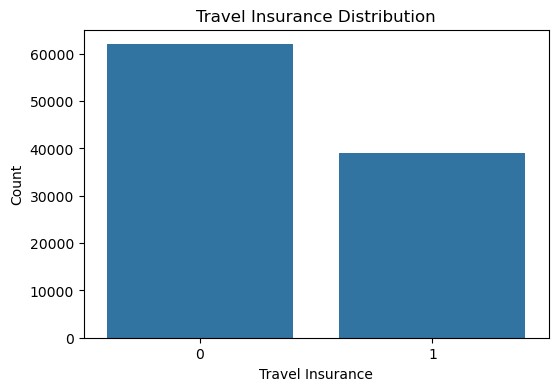

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TravelInsurance', data=df)
plt.title('Travel Insurance Distribution')
plt.xlabel('Travel Insurance')
plt.ylabel('Count')
plt.show()

## Outlier Analysis

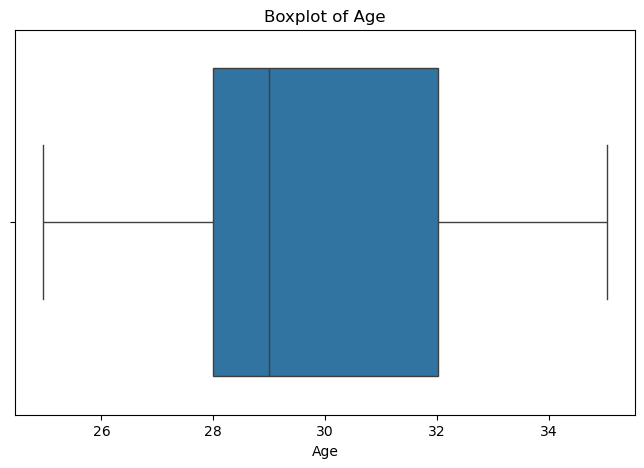

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age')
plt.show()

# Observation: There are no outliers in Age.
# The Age values are concentrated within a relatively narrow range.

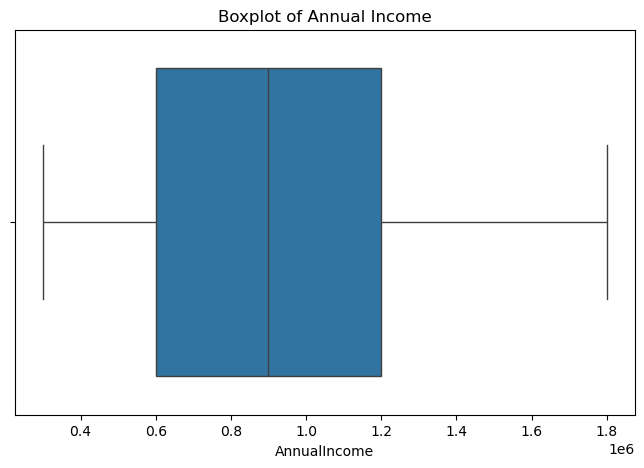

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['AnnualIncome'])
plt.title('Boxplot of Annual Income')
plt.show()

# Observation: There are no visible outliers in AnnualIncome.
# Most AnnualIncome values are concentrated between 0.6 and 1.2 million.

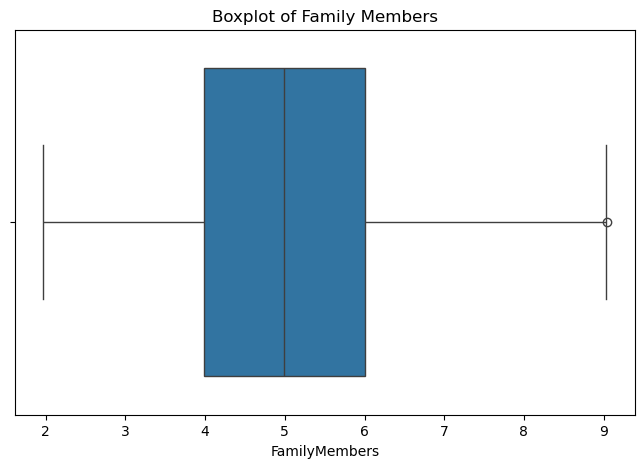

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['FamilyMembers'])
plt.title('Boxplot of Family Members')
plt.show()

# Observation: There is one possible outlier in FamilyMembers.

# Most of the FamilyMembers values are between 4 and 6.

# I checked the outlier and there was no clear error, so I kept it.


In [19]:
df['TravelInsurance'] = (df['TravelInsurance'] >= 0.5).astype(int)

# CATEGORICAL EDA

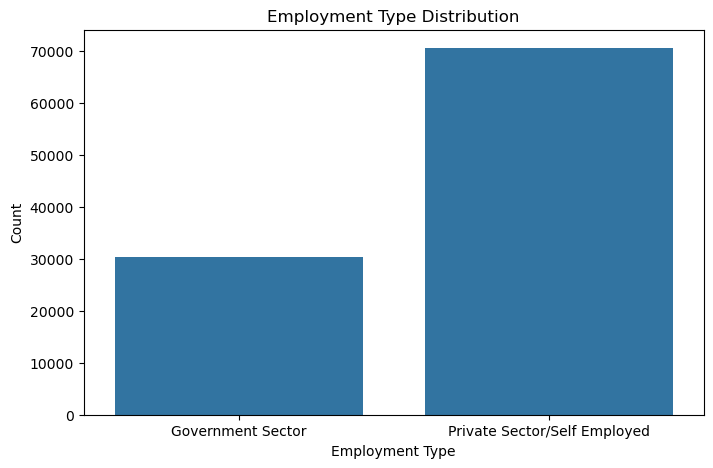

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Employment Type', data=df)
plt.title('Employment Type Distribution')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.show()

# Observation: Most customers are from the Private Sector/Self Employed category.
# The number of Government Sector customers is lower.

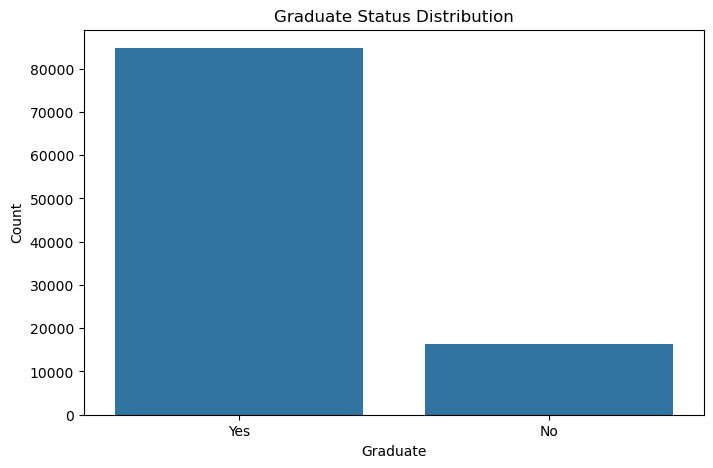

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(x='GraduateOrNot', data=df)
plt.title('Graduate Status Distribution')
plt.xlabel('Graduate')
plt.ylabel('Count')
plt.show()

# Observation: Most customers are Graduates.
# The number of Non-Graduates is lower.

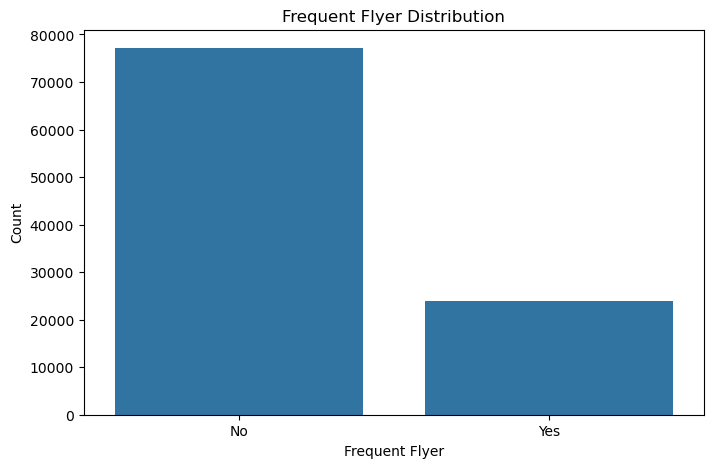

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='FrequentFlyer', data=df)
plt.title('Frequent Flyer Distribution')
plt.xlabel('Frequent Flyer')
plt.ylabel('Count')
plt.show()

# Observation: Most customers are not frequent flyers.

# The number of frequent flyers is lower.

# It means most customers do not travel thorugh flights frequently


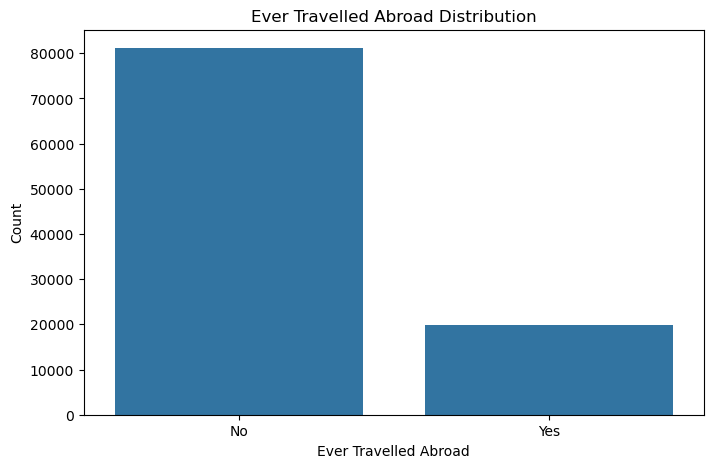

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='EverTravelledAbroad', data=df)
plt.title('Ever Travelled Abroad Distribution')
plt.xlabel('Ever Travelled Abroad')
plt.ylabel('Count')
plt.show()

# Observation: Most customers have not travelled abroad.

# The number of customers who have travelled abroad is lower.


In [24]:
plot_data=pd.crosstab(df['Employment Type'], df['TravelInsurance'])
plot_data

TravelInsurance,0,1
Employment Type,,
Government Sector,18543,11853
Private Sector/Self Employed,43438,27166


# Observation: In both employment groups, more customers did not purchase travel insurance.
# The Private Sector/Self Employed group has more customers overall.

In [25]:
graduate_data = pd.crosstab(df['GraduateOrNot'], df['TravelInsurance'])
graduate_data

TravelInsurance,0,1
GraduateOrNot,,
No,9961,6290
Yes,52020,32729


# **Observation:** From the crosstab, both graduates and non-graduates have more customers who did not purchase travel insurance than those who purchased it. The graduate group has higher overall customer counts because there are more graduates in the dataset.


In [26]:
df['AnnualIncome'].describe()

count    1.010000e+05
mean     9.328525e+05
std      3.608964e+05
min      3.000000e+05
25%      6.000000e+05
50%      9.000000e+05
75%      1.200000e+06
max      1.800000e+06
Name: AnnualIncome, dtype: float64

# **Observation:** The AnnualIncome ranges from ₹3 lakh to ₹18 lakh, with an average income of about ₹9.33 lakh. The median income is ₹9 lakh.


In [27]:
Q1 = df['AnnualIncome'].quantile(0.25)
Q3 = df['AnnualIncome'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -300000.00232655986
Upper Bound: 2100000.024179241


In [28]:
df.select_dtypes(include='number').columns

Index(['Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases',
       'TravelInsurance'],
      dtype='object')

In [29]:
numeric_cols = ['Age', 'AnnualIncome', 'FamilyMembers']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
AnnualIncome: 0 outliers
FamilyMembers: 1 outliers


In [30]:
df['FamilyMembers'].min(), df['FamilyMembers'].max()

(1.9650304890878827, 9.039589132140463)

# **Observation:** Using the IQR method, no outliers were detected in Age or AnnualIncome. One potential outlier was detected in FamilyMembers. After investigating the record, no clear data-entry error was found, so the value was retained for further analysis.


In [31]:
df['FamilyMembers'].describe()

count    101000.000000
mean          4.888434
std           1.760306
min           1.965030
25%           3.981089
50%           4.991322
75%           6.003040
max           9.039589
Name: FamilyMembers, dtype: float64

In [32]:
df[df['FamilyMembers'] == df['FamilyMembers'].max()]


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
58375,27.987618,Government Sector,Yes,1.450000e+06,9.039589,0.005297,No,No,1


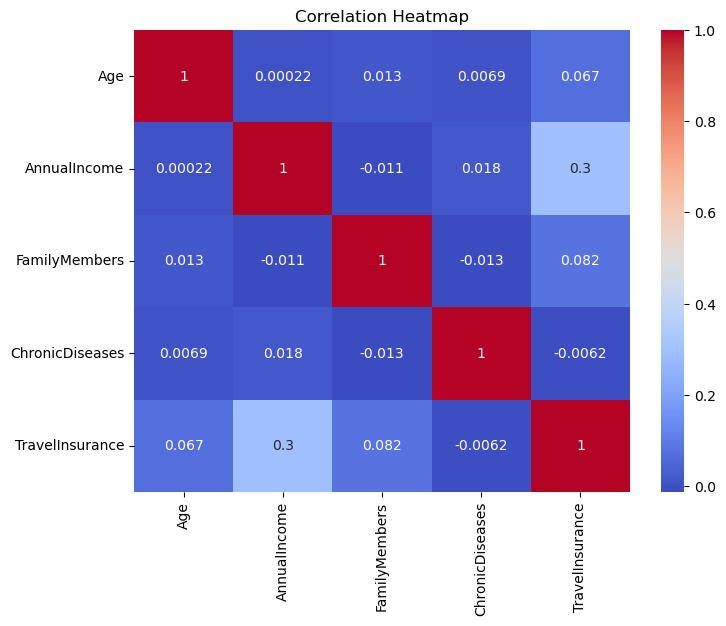

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
        df[['Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'TravelInsurance']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# Correlation Analysis Observation: AnnualIncome has the strongest positive correlation with TravelInsurance (0.295), indicating a moderate positive association. Age (0.067) and FamilyMembers (0.082) have very weak positive correlations, while ChronicDiseases (-0.006) has almost no linear correlation with TravelInsurance.

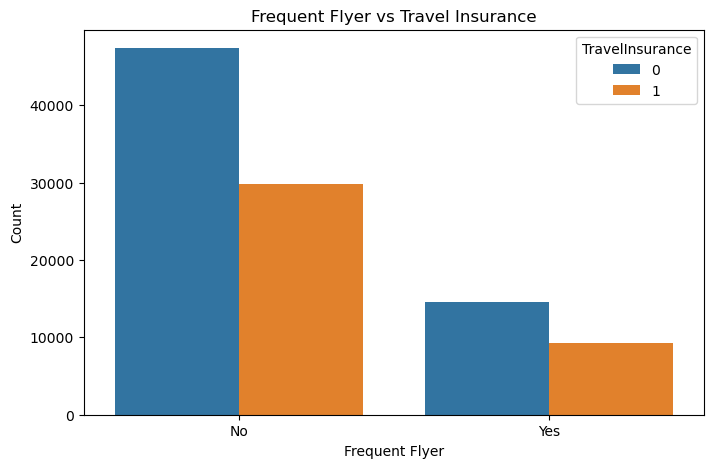

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(x='FrequentFlyer', hue='TravelInsurance', data=df)

plt.title('Frequent Flyer vs Travel Insurance')
plt.xlabel('Frequent Flyer')
plt.ylabel('Count')
plt.show()

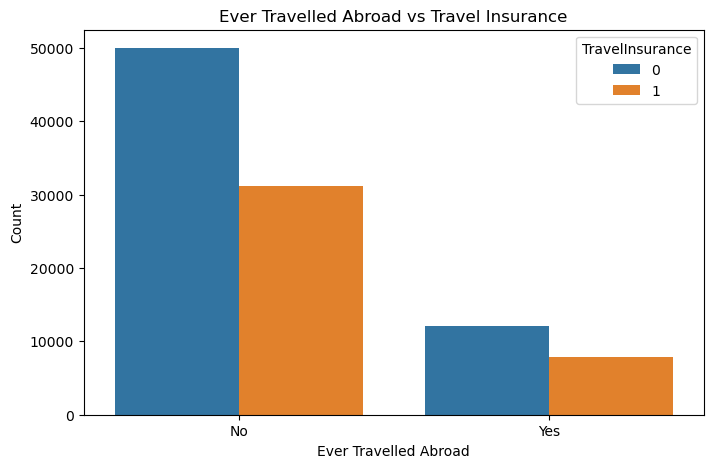

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(x='EverTravelledAbroad', hue='TravelInsurance', data=df)

plt.title('Ever Travelled Abroad vs Travel Insurance')
plt.xlabel('Ever Travelled Abroad')
plt.ylabel('Count')
plt.show()

 # Observation:** Customers who have not travelled abroad are higher in number than those who have travelled abroad. In both groups, the number of customers who did not purchase travel insurance is higher than the number who purchased it. The customers who have travelled abroad show a slightly higher proportion of travel insurance purchases compared with those who have not travelled abroad.


## 3. Model Building and Evaluation
# Splitting X (Indepedent variable) and Y (Dependent variable)
# *x* contains the customer characteristics used to make predictions.
# y contains the target variable, `TravelInsurance`, which indicates whether the customer purchased travel insurance.

In [36]:
df['ChronicDiseases'] = (df['ChronicDiseases'] >= 0.5).astype(int)

In [37]:
x = df.drop('TravelInsurance', axis=1)
y = df['TravelInsurance']
print(x.shape)
print(y.shape)

(101000, 8)
(101000,)


# Encoding categorical variables

In [38]:
x = pd.get_dummies(x, drop_first=True)

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=57,stratify=y)
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(70700, 8) (30300, 8)
(70700,) (30300,)


# Logistic Regression Model

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *


In [42]:
lr1 = LogisticRegression(max_iter=10000)
lr1.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [43]:
x.dtypes

Age                                             float64
AnnualIncome                                    float64
FamilyMembers                                   float64
ChronicDiseases                                   int64
Employment Type_Private Sector/Self Employed       bool
GraduateOrNot_Yes                                  bool
FrequentFlyer_Yes                                  bool
EverTravelledAbroad_Yes                            bool
dtype: object

In [44]:
x.head()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,Employment Type_Private Sector/Self Employed,GraduateOrNot_Yes,FrequentFlyer_Yes,EverTravelledAbroad_Yes
0,30.999900,9.000000e+05,3.003979,0,False,True,False,False
1,25.990394,1.300000e+06,5.004967,0,False,True,True,True
2,33.992974,1.300000e+06,4.013509,1,False,True,False,False
3,33.000537,4.000000e+05,6.012644,0,False,True,False,False
4,32.001252,3.500000e+05,2.997488,1,True,True,False,False


In [45]:
x.dtypes

Age                                             float64
AnnualIncome                                    float64
FamilyMembers                                   float64
ChronicDiseases                                   int64
Employment Type_Private Sector/Self Employed       bool
GraduateOrNot_Yes                                  bool
FrequentFlyer_Yes                                  bool
EverTravelledAbroad_Yes                            bool
dtype: object

In [46]:
ypred_lr1=lr1.predict(x_test)

In [47]:
lr1_accuracy = accuracy_score(y_test, ypred_lr1)

print("Logistic Regression Accuracy:", lr1_accuracy)

Logistic Regression Accuracy: 0.664092409240924


## Random Forest Model

In [48]:
rf1 = RandomForestClassifier()
rf1.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
ypred_rf1 = rf1.predict(x_test)

rf1_accuracy = accuracy_score(y_test, ypred_rf1)

print("Random Forest Accuracy:", rf1_accuracy)

Random Forest Accuracy: 0.8356435643564356


### Observation

- Logistic Regression achieved an accuracy of **66.41%**.
- Random Forest achieved an accuracy of **83.56%**.
- Random Forest performed better than Logistic Regression on the test dataset.
- Therefore, **Random Forest is the more accurate model** for predicting travel insurance purchases in this analysis.